# J02 — L'eau du sol : teneur en eau et état énergétique

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 2 : unités du potentiel, tensiomètres et charge hydraulique, loi de Jurin, étalonnage TDR et stock d'eau*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les données sont dans le dossier `data/`. Convention du cours : $z$ positif vers le haut, origine à la surface du sol ;
charge hydraulique $H = h + z$ (cm) ; eau à 20 °C ($\rho_w = 998{,}2$ kg/m³, $g = 9{,}81$ m/s², $\sigma = 72{,}8$ mN/m).
Exécutez la cellule suivante pour importer les bibliothèques et définir les constantes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rho_w = 998.2    # masse volumique de l'eau à 20 °C, kg/m³
g = 9.81         # accélération de la pesanteur, m/s²
sigma = 0.0728   # tension superficielle de l'eau à 20 °C, N/m

## Exercice 1 — Unités du potentiel et échelle pF  *(≈ 10 min)*

Le potentiel de l'eau s'exprime par unité de masse ($\psi$, J/kg), de volume ($\Psi = \rho_w \psi$, Pa) ou de poids
($h = \psi/g$, m ou cm de colonne d'eau). Rappels : $1$ kPa $= 1000/(\rho_w g)$ m $\approx 10{,}2$ cm ; $1$ bar $= 100$ kPa ;
$\mathrm{pF} = \log_{10}(|h|$ en cm$)$.

1. Convertir $\Psi = -1500$ kPa (point de flétrissement) en bar, en m et cm de colonne d'eau et en J/kg, en passant par
   l'unité pivot (le Pa).
2. Calculer le pF correspondant (le pF n'est défini que pour $h < 0$).
3. Construire la table des états remarquables pour $\Psi = -1, -10, -33, -100, -1500$ kPa : valeur en bar, cm, m, J/kg et pF.
4. Vérifier que pF $= \log_{10}(|\Psi|_{\mathrm{kPa}}) + 1{,}01$.

**1. Conversion de −1500 kPa**

In [2]:
Psi_kPa = -1500.0      # point de flétrissement permanent

# unité pivot : le pascal (1 kPa = 1000 Pa ; 1 Pa = 1 J/m³ ; 1 bar = 1e5 Pa)
Psi_Pa = Psi_kPa * 1000
Psi_bar = Psi_Pa / 1e5

# par unité de poids : h = Psi / (rho_w g), en m puis en cm de colonne d'eau
h_m = Psi_Pa / (rho_w * g)
h_cm = h_m * 100

# par unité de masse : psi = Psi / rho_w, en J/kg
psi_Jkg = Psi_Pa / rho_w

print("Psi =", Psi_kPa, "kPa =", Psi_bar, "bar")
print("h =", round(h_m, 3), "m =", round(h_cm, 1), "cm de colonne d'eau")
print("psi =", round(psi_Jkg, 2), "J/kg")

Psi = -1500.0 kPa = -15.0 bar
h = -153.181 m = -15318.1 cm de colonne d'eau
psi = -1502.7 J/kg


**2. Échelle pF**

In [3]:
# pF = log10(|h| en cm), défini seulement pour une succion (h < 0)
if h_cm < 0:
    pF = np.log10(-h_cm)
else:
    pF = np.nan
print("pF du point de flétrissement =", round(pF, 3))

pF du point de flétrissement = 4.185


**3. Table des états remarquables**

In [4]:
etats = pd.DataFrame({
    "etat": ["saturation proche", "capacité au champ (sable)", "capacité au champ", "pF 3 (approx.)", "point de flétrissement"],
    "Psi_kPa": [-1, -10, -33, -100, -1500],
})

# mêmes conversions que ci-dessus, appliquées à toute la colonne
etats["bar"] = etats["Psi_kPa"] / 100
etats["cm"] = etats["Psi_kPa"] * 1000 / (rho_w * g) * 100
etats["m"] = etats["cm"] / 100
etats["J/kg"] = etats["Psi_kPa"] * 1000 / rho_w
etats["pF"] = np.log10(-etats["cm"])
print(etats.round(3))

                        etat  Psi_kPa    bar         cm        m      J/kg  \
0          saturation proche       -1  -0.01    -10.212   -0.102    -1.002   
1  capacité au champ (sable)      -10  -0.10   -102.121   -1.021   -10.018   
2          capacité au champ      -33  -0.33   -336.998   -3.370   -33.060   
3             pF 3 (approx.)     -100  -1.00  -1021.206  -10.212  -100.180   
4     point de flétrissement    -1500 -15.00 -15318.092 -153.181 -1502.705   

      pF  
0  1.009  
1  2.009  
2  2.528  
3  3.009  
4  4.185  


**4. Règle rapide pF = log10(|Psi| en kPa) + 1,01**

In [5]:
etats["log10_kPa"] = np.log10(-etats["Psi_kPa"])
etats["pF - log10_kPa"] = etats["pF"] - etats["log10_kPa"]
print(etats[["etat", "pF", "log10_kPa", "pF - log10_kPa"]].round(3))

# la constante est le log10 du nombre de cm de colonne d'eau par kPa
cm_par_kPa = 1000 / (rho_w * g) * 100
print("cm par kPa =", round(cm_par_kPa, 3), "; constante exacte = log10(cm par kPa) =", round(np.log10(cm_par_kPa), 3))

                        etat     pF  log10_kPa  pF - log10_kPa
0          saturation proche  1.009      0.000           1.009
1  capacité au champ (sable)  2.009      1.000           1.009
2          capacité au champ  2.528      1.519           1.009
3             pF 3 (approx.)  3.009      2.000           1.009
4     point de flétrissement  4.185      3.176           1.009
cm par kPa = 10.212 ; constante exacte = log10(cm par kPa) = 1.009


**Commentaire (instructeur).** La constante 1,009 relie pF et $\log_{10}|\Psi|$ en kPa ; le point de flétrissement (−1500 kPa) vaut −15 320 cm, soit pF 4,19 (arrondi 4,2).
La conversion kPa → J/kg est quasi identique (facteur 1,002) : les deux unités sont interchangeables à 0,2 % près.

## Exercice 2 — Tensiomètres : charge hydraulique et sens de l'écoulement  *(≈ 20 min)*

`data/J02_tensiometres.csv` : six tensiomètres à jauge à vide installés à 15, 30, 45, 60, 90 et 120 cm de profondeur dans un loam.
Pour chaque tensiomètre : `lecture_kPa` (succion $S$ lue par la jauge, positive) et `L_col_cm` (hauteur de la jauge au-dessus
de la bougie). Deux dates : après une pluie, puis après sept jours sans pluie.

1. Calculer la charge de pression à la bougie $h = -10{,}2\,S + L$ (cm), la cote $z = -$profondeur et la charge hydraulique $H = h + z$.
2. Tracer $h(z)$ et $H(z)$ pour les deux dates (cote $z$ en ordonnée).
3. Entre tensiomètres voisins, calculer le gradient $\Delta H/\Delta z = (H_{\text{haut}} - H_{\text{bas}})/(z_{\text{haut}} - z_{\text{bas}})$
   et en déduire le sens du flux (gradient $> 0$ : vers le bas ; $< 0$ : vers le haut) et son intensité relative.
4. Localiser, à la seconde date, le plan de flux nul (changement de signe du gradient : interpoler la cote où $\Delta H/\Delta z = 0$).

**Lecture des données**

In [6]:
tens = pd.read_csv("data/J02_tensiometres.csv")
print(tens)

                           date  profondeur_cm  L_col_cm  lecture_kPa
0      2025-06-03 (après pluie)             15        35          7.2
1      2025-06-03 (après pluie)             30        50          8.5
2      2025-06-03 (après pluie)             45        65         10.1
3      2025-06-03 (après pluie)             60        80         11.9
4      2025-06-03 (après pluie)             90       110         14.9
5      2025-06-03 (après pluie)            120       140         18.4
6   2025-06-10 (après 7 j secs)             15        35         47.7
7   2025-06-10 (après 7 j secs)             30        50         34.4
8   2025-06-10 (après 7 j secs)             45        65         24.3
9   2025-06-10 (après 7 j secs)             60        80         19.5
10  2025-06-10 (après 7 j secs)             90       110         18.8
11  2025-06-10 (après 7 j secs)            120       140         20.6


**1. Charge de pression, cote et charge hydraulique**

In [7]:
cm_par_kPa = 1000 / (rho_w * g) * 100      # cm de colonne d'eau par kPa (10,21)

# charge de pression à la bougie : la jauge lit la succion S, la colonne d'eau de hauteur L s'ajoute
tens["h_cm"] = -tens["lecture_kPa"] * cm_par_kPa + tens["L_col_cm"]
# cote (z positif vers le haut, origine à la surface) et charge hydraulique
tens["z_cm"] = -tens["profondeur_cm"]
tens["H_cm"] = tens["h_cm"] + tens["z_cm"]
print(tens.round(1))

                           date  profondeur_cm  L_col_cm  lecture_kPa   h_cm  \
0      2025-06-03 (après pluie)             15        35          7.2  -38.5   
1      2025-06-03 (après pluie)             30        50          8.5  -36.8   
2      2025-06-03 (après pluie)             45        65         10.1  -38.1   
3      2025-06-03 (après pluie)             60        80         11.9  -41.5   
4      2025-06-03 (après pluie)             90       110         14.9  -42.2   
5      2025-06-03 (après pluie)            120       140         18.4  -47.9   
6   2025-06-10 (après 7 j secs)             15        35         47.7 -452.1   
7   2025-06-10 (après 7 j secs)             30        50         34.4 -301.3   
8   2025-06-10 (après 7 j secs)             45        65         24.3 -183.2   
9   2025-06-10 (après 7 j secs)             60        80         19.5 -119.1   
10  2025-06-10 (après 7 j secs)             90       110         18.8  -82.0   
11  2025-06-10 (après 7 j secs)         

**2. Profils h(z) et H(z)**

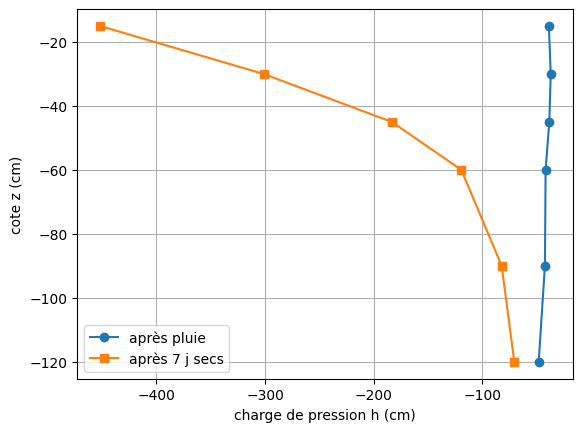

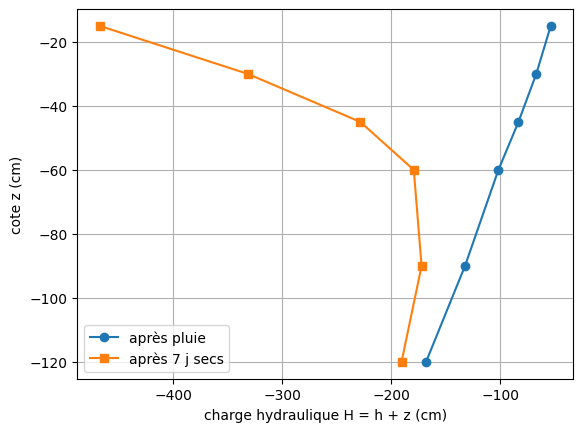

In [8]:
# une table par date
pluie = tens[tens["date"] == "2025-06-03 (après pluie)"]
sec = tens[tens["date"] == "2025-06-10 (après 7 j secs)"]

plt.figure()
plt.plot(pluie["h_cm"], pluie["z_cm"], "o-", label="après pluie")
plt.plot(sec["h_cm"], sec["z_cm"], "s-", label="après 7 j secs")
plt.xlabel("charge de pression h (cm)")
plt.ylabel("cote z (cm)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(pluie["H_cm"], pluie["z_cm"], "o-", label="après pluie")
plt.plot(sec["H_cm"], sec["z_cm"], "s-", label="après 7 j secs")
plt.xlabel("charge hydraulique H = h + z (cm)")
plt.ylabel("cote z (cm)")
plt.legend()
plt.grid(True)
plt.show()

**3. Gradients de charge entre tensiomètres voisins**

In [9]:
profondeur = pluie["profondeur_cm"].to_numpy()
z = pluie["z_cm"].to_numpy()
H_pluie = pluie["H_cm"].to_numpy()
H_sec = sec["H_cm"].to_numpy()

lignes = []
for i in range(len(z) - 1):
    # i = tensiomètre du haut, i + 1 = tensiomètre du bas
    dz = z[i] - z[i + 1]
    grad_pluie = (H_pluie[i] - H_pluie[i + 1]) / dz
    grad_sec = (H_sec[i] - H_sec[i + 1]) / dz
    if grad_pluie > 0:
        sens_pluie = "vers le bas"
    else:
        sens_pluie = "vers le haut"
    if grad_sec > 0:
        sens_sec = "vers le bas"
    else:
        sens_sec = "vers le haut"
    intervalle = f"{profondeur[i]}-{profondeur[i + 1]} cm"
    z_milieu = (z[i] + z[i + 1]) / 2
    lignes.append([intervalle, z_milieu, grad_pluie, sens_pluie, grad_sec, sens_sec])

grad = pd.DataFrame(lignes, columns=["intervalle", "z_milieu_cm", "dHdz_pluie", "sens_pluie", "dHdz_sec", "sens_sec"])
print(grad.round(2))

  intervalle  z_milieu_cm  dHdz_pluie   sens_pluie  dHdz_sec      sens_sec
0   15-30 cm        -22.5        0.89  vers le bas     -9.05  vers le haut
1   30-45 cm        -37.5        1.09  vers le bas     -6.88  vers le haut
2   45-60 cm        -52.5        1.23  vers le bas     -3.27  vers le haut
3   60-90 cm        -75.0        1.02  vers le bas     -0.24  vers le haut
4  90-120 cm       -105.0        1.19  vers le bas      0.61   vers le bas


**4. Plan de flux nul (seconde date)**

In [10]:
z_milieu = grad["z_milieu_cm"].to_numpy()
dHdz = grad["dHdz_sec"].to_numpy()

# on cherche deux intervalles voisins où le gradient passe de négatif (flux montant) à positif (flux descendant)
z_flux_nul = np.nan
for i in range(len(dHdz) - 1):
    if dHdz[i] < 0 and dHdz[i + 1] > 0:
        # interpolation linéaire entre les deux milieux d'intervalle (np.interp veut des abscisses croissantes)
        z_flux_nul = np.interp(0, [dHdz[i], dHdz[i + 1]], [z_milieu[i], z_milieu[i + 1]])

if np.isnan(z_flux_nul):
    print("Pas de changement de signe : flux de même sens sur tout le profil.")
else:
    print("Plan de flux nul (2e date) vers z =", round(z_flux_nul), "cm : évaporation au-dessus, drainage en dessous.")

Plan de flux nul (2e date) vers z = -83 cm : évaporation au-dessus, drainage en dessous.


**Commentaire (instructeur).** Après la pluie, $h$ est presque uniforme (−37 à −48 cm) : le gradient de $H$ vaut ≈ 1 partout, l'eau draine vers le bas sous
gradient unitaire. Après sept jours secs, $h$ chute à −450 cm en surface : le gradient est négatif (flux ascendant, évaporation)
jusque vers 80–85 cm, puis redevient positif (drainage) : c'est le plan de flux nul. Noter que la correction de colonne
($+L$) change $h$ de 35 à 140 cm : l'oublier fausse complètement les gradients.

## Exercice 3 — Loi de Jurin et distribution des tailles de pores  *(≈ 15 min)*

La loi de Jurin relie la charge de pression $h$ au rayon du plus gros pore encore plein d'eau :
$|h| = 2\sigma\cos\gamma/(\rho_w g\, r)$, soit $r\,[\mathrm{cm}] \approx 0{,}149/|h|\,[\mathrm{cm}]$ à 20 °C ($\gamma = 0$).

1. Calculer le rayon de pore équivalent `rayon_jurin(h_cm, T)` (µm) et la charge de pression `h_jurin(r_um, T)` (cm), avec
   $\sigma(T)$ interpolée dans la table : 0 °C : 75,6 ; 10 °C : 74,2 ; 20 °C : 72,8 ; 30 °C : 71,2 ; 40 °C : 69,6 mN/m.
   Vérifier le facteur 0,149 à 20 °C et calculer la remontée capillaire pour $r$ = 1, 10, 100 et 1000 µm.
2. `data/J02_retention.csv` : courbes $\theta(h)$ (drainage) d'un sable et d'un loam. Calculer $r$ pour chaque point, puis la
   densité de distribution des tailles de pores $f(r) = \mathrm{d}\theta/\mathrm{d}\log_{10} r$ (`np.gradient`). Tracer $f$ en fonction de $r$ (échelle log).
3. Pour chaque sol : rayon modal, fraction du volume poral ($\theta_s - \theta_r$, avec $\theta_r = \theta(-10^5$ cm$)$)
   correspondant aux macropores ($r > 30$ µm) et aux pores $< 0{,}1$ µm.

**1. Loi de Jurin : rayon équivalent et remontée capillaire**

In [11]:
T_tab = np.array([0, 10, 20, 30, 40])                           # °C
sigma_tab = np.array([75.6, 74.2, 72.8, 71.2, 69.6]) * 1e-3     # N/m

# rayon de pore équivalent (µm) qui se vide à la charge de pression h (cm), angle de contact nul
def rayon_jurin(h_cm, T):
    sigma_T = np.interp(T, T_tab, sigma_tab)
    h_m = np.abs(h_cm) / 100
    r_m = 2 * sigma_T / (rho_w * g * h_m)
    return r_m * 1e6

# charge de pression (cm, négative) à laquelle un pore de rayon r (µm) se vide
def h_jurin(r_um, T):
    sigma_T = np.interp(T, T_tab, sigma_tab)
    r_m = r_um * 1e-6
    h_m = 2 * sigma_T / (rho_w * g * r_m)
    return -h_m * 100

# facteur |h| * r en cm² : 2 sigma / (rho_w g) en m², fois 1e4
facteur = 2 * sigma / (rho_w * g) * 1e4
print("facteur 2 sigma / (rho_w g) à 20 °C =", round(facteur, 4), "cm²  (0,149 attendu)")
for r_um in [1, 10, 100, 1000]:
    print("r =", r_um, "µm : remontée capillaire =", round(-h_jurin(r_um, 20), 1), "cm")

facteur 2 sigma / (rho_w g) à 20 °C = 0.1487 cm²  (0,149 attendu)
r = 1 µm : remontée capillaire = 1486.9 cm
r = 10 µm : remontée capillaire = 148.7 cm
r = 100 µm : remontée capillaire = 14.9 cm
r = 1000 µm : remontée capillaire = 1.5 cm


**Lecture des courbes de rétention**

     h_cm  theta_sable  theta_loam
0  -1.000       0.4286      0.4293
1  -1.343       0.4270      0.4289
2  -1.805       0.4235      0.4282
3  -2.424       0.4160      0.4272
4  -3.257       0.4008      0.4256
5  -4.375       0.3723      0.4232
6  -5.878       0.3261      0.4194
7  -7.897       0.2652      0.4138
8 -10.608       0.2023      0.4055
9 -14.251       0.1496      0.3938
nombre de points : 40


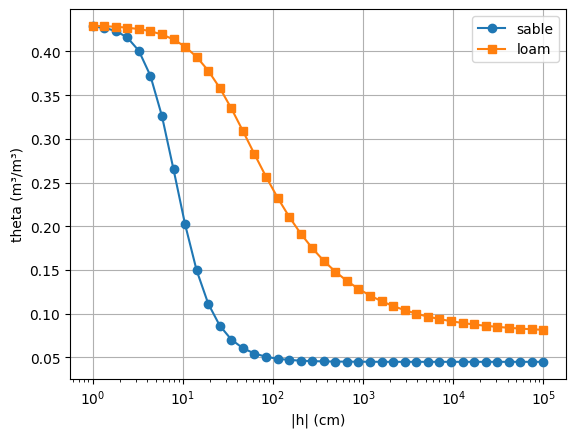

In [12]:
ret = pd.read_csv("data/J02_retention.csv")
print(ret.head(10))
print("nombre de points :", len(ret))

plt.figure()
plt.semilogx(-ret["h_cm"], ret["theta_sable"], "o-", label="sable")
plt.semilogx(-ret["h_cm"], ret["theta_loam"], "s-", label="loam")
plt.xlabel("|h| (cm)")
plt.ylabel("theta (m³/m³)")
plt.legend()
plt.grid(True)
plt.show()

**2. Rayon équivalent et distribution des tailles de pores**

      h_cm       r_um  theta_sable  f_sable  theta_loam  f_loam
0   -1.000  1486.8762       0.4286   0.0125      0.4293  0.0031
1   -1.343  1107.1304       0.4270   0.0199      0.4289  0.0043
2   -1.805   823.7541       0.4235   0.0429      0.4282  0.0066
3   -2.424   613.3978       0.4160   0.0885      0.4272  0.0101
4   -3.257   456.5171       0.4008   0.1705      0.4256  0.0156
5   -4.375   339.8574       0.3723   0.2913      0.4232  0.0242
6   -5.878   252.9561       0.3261   0.4176      0.4194  0.0367
7   -7.897   188.2837       0.2652   0.4828      0.4138  0.0542
8  -10.608   140.1656       0.2023   0.4509      0.4055  0.0780
9  -14.251   104.3349       0.1496   0.3537      0.3938  0.1069
10 -19.145    77.6639       0.1116   0.2465      0.3781  0.1385
11 -25.719    57.8124       0.0864   0.1603      0.3583  0.1685
12 -34.551    43.0342       0.0705   0.1006      0.3349  0.1919
13 -46.416    32.0337       0.0606   0.0624      0.3091  0.2040
14 -62.355    23.8453       0.0545   0.0

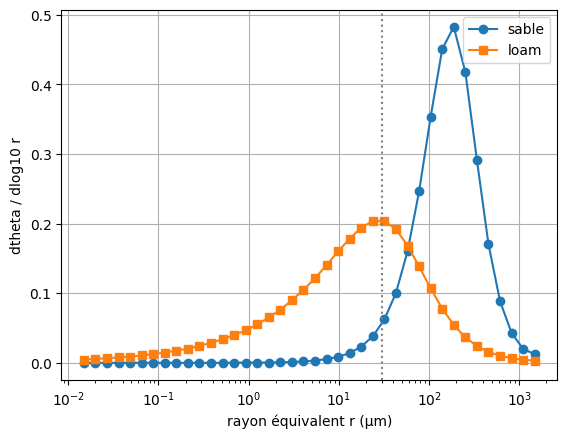

In [13]:
# rayon équivalent (µm) de chaque point de la courbe
ret["r_um"] = rayon_jurin(ret["h_cm"], 20)
log_r = np.log10(ret["r_um"].to_numpy())

# densité f = dtheta / dlog10(r), par différence finie (np.gradient) ; f > 0 car theta diminue avec r
theta_sable = ret["theta_sable"].to_numpy()
theta_loam = ret["theta_loam"].to_numpy()
ret["f_sable"] = np.gradient(theta_sable, log_r)
ret["f_loam"] = np.gradient(theta_loam, log_r)
print(ret[["h_cm", "r_um", "theta_sable", "f_sable", "theta_loam", "f_loam"]].head(15).round(4))

plt.figure()
plt.semilogx(ret["r_um"], ret["f_sable"], "o-", label="sable")
plt.semilogx(ret["r_um"], ret["f_loam"], "s-", label="loam")
plt.axvline(30, color="gray", linestyle=":")    # limite des macropores (30 µm)
plt.xlabel("rayon équivalent r (µm)")
plt.ylabel("dtheta / dlog10 r")
plt.legend()
plt.grid(True)
plt.show()

**3. Rayon modal et fractions de pores**

In [14]:
# log10 |h| croît avec les lignes du tableau : on interpole theta en fonction de log10 |h|
log_h = np.log10(-ret["h_cm"].to_numpy())
log_h_30 = np.log10(-h_jurin(30, 20))      # |h| auquel un pore de 30 µm se vide
log_h_01 = np.log10(-h_jurin(0.1, 20))     # |h| auquel un pore de 0,1 µm se vide

resultats = []
for sol in ["sable", "loam"]:
    theta = ret["theta_" + sol].to_numpy()
    f = ret["f_" + sol].to_numpy()
    # rayon modal = rayon où la densité f est maximale
    i_max = np.argmax(f)
    r_modal = ret.loc[i_max, "r_um"]
    h_modal = h_jurin(r_modal, 20)
    # theta_s au premier point (h = -1 cm), theta_r au dernier (h = -1e5 cm)
    theta_s = theta[0]
    theta_r = theta[-1]
    theta_30 = np.interp(log_h_30, log_h, theta)
    theta_01 = np.interp(log_h_01, log_h, theta)
    frac_macro = (theta_s - theta_30) / (theta_s - theta_r)
    frac_fins = (theta_01 - theta_r) / (theta_s - theta_r)
    resultats.append([sol, theta_s, theta_r, r_modal, h_modal, frac_macro, frac_fins])

res = pd.DataFrame(resultats, columns=["sol", "theta_s", "theta_r", "r_modal_um", "h_modal_cm", "frac_macropores", "frac_inf_0p1um"])
print(res.round(3))

     sol  theta_s  theta_r  r_modal_um  h_modal_cm  frac_macropores  \
0  sable    0.429    0.045     188.284      -7.897            0.963   
1   loam    0.429    0.082      23.845     -62.355            0.363   

   frac_inf_0p1um  
0            0.00  
1            0.02  


**Commentaire (instructeur).** Le sable a un pic étroit vers 200 µm (|h| ≈ 8 cm) : plus de 90 % de son volume poral est constitué de macropores qui se vident
dès les premiers centimètres de succion. Le loam a un mode vers 25 µm (|h| ≈ 60 cm ; analytiquement $|h| = m^{-1/n}/\alpha$)
mais une distribution très étalée : ~35 % du volume poral dans les macropores et ~2 % de pores < 0,1 µm, dont
l'eau (pF > 4,2) est inaccessible aux plantes.
Aux très faibles rayons (< 0,05 µm), le « rayon » n'a plus de sens géométrique : la rétention est due à l'adsorption.

## Exercice 4 — Étalonnage TDR et stock d'eau d'un profil  *(≈ 15 min)*

1. `data/J02_tdr_etalonnage.csv` : 30 couples ($\varepsilon_a$, $\theta_{\text{grav}}$) mesurés sur un loam riche en matière
   organique. Ajuster un polynôme de degré 3 $\theta = a_0 + a_1\varepsilon_a + a_2\varepsilon_a^2 + a_3\varepsilon_a^3$
   (`np.polyfit`) et le tracer avec l'équation de Topp et al. (1980) :
   $\theta = -5{,}3\times10^{-2} + 2{,}92\times10^{-2}\varepsilon_a - 5{,}5\times10^{-4}\varepsilon_a^2 + 4{,}3\times10^{-6}\varepsilon_a^3$.
2. Calculer le RMSE et le biais moyen de chaque étalonnage par rapport aux mesures gravimétriques.
3. `data/J02_tdr_profils.csv` : $\varepsilon_a$ mesurée à 8 profondeurs (10 à 100 cm) à trois dates ; 32 mm de pluie sont tombés
   entre les dates 2 et 3. Convertir en $\theta$ avec les deux étalonnages, tracer les profils.
4. Calculer le stock d'eau $W$ (mm) sur 0–100 cm par la méthode des trapèzes (`np.trapezoid`), en supposant $\theta$ constant entre
   la surface et la première sonde. Comparer les deux étalonnages.
5. Calculer la variation de stock entre les dates avec les deux étalonnages et la comparer à la pluie de 32 mm.

**Lecture des données d'étalonnage**

In [15]:
cal = pd.read_csv("data/J02_tdr_etalonnage.csv")
eps = cal["eps_a"].to_numpy()             # permittivité apparente mesurée par TDR
theta_grav = cal["theta_grav"].to_numpy() # teneur en eau de référence (gravimétrie)
print(cal.head())
print("nombre de couples :", len(cal))

   eps_a  theta_grav
0   3.53       0.075
1   4.46       0.095
2   4.90       0.096
3   7.40       0.171
4   7.47       0.143
nombre de couples : 30


**1. Polynôme local de degré 3 et équation de Topp**

coefficients (a3, a2, a1, a0) : [ 6.0000e-06 -6.8000e-04  3.2567e-02 -4.0562e-02]


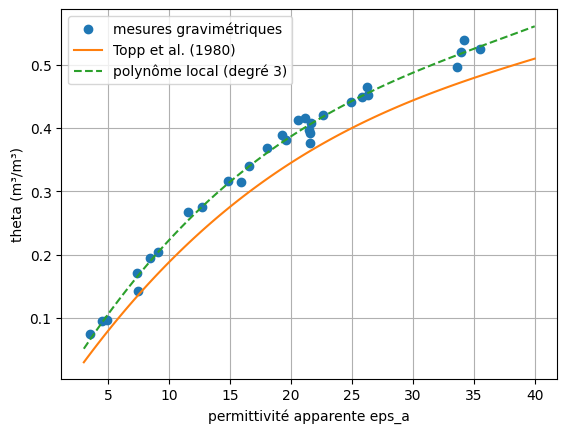

In [16]:
# équation de Topp et al. (1980) : theta en fonction de la permittivité apparente eps
def topp(eps):
    theta = -5.3e-2 + 2.92e-2 * eps - 5.5e-4 * eps**2 + 4.3e-6 * eps**3
    return theta

# polynôme de degré 3 ajusté aux mesures ; np.polyfit renvoie les coefficients (a3, a2, a1, a0)
coef = np.polyfit(eps, theta_grav, 3)
print("coefficients (a3, a2, a1, a0) :", np.round(coef, 6))

# np.polyval(coef, x) évalue le polynôme en x
eps_trace = np.linspace(3, 40, 100)
plt.figure()
plt.plot(eps, theta_grav, "o", label="mesures gravimétriques")
plt.plot(eps_trace, topp(eps_trace), "-", label="Topp et al. (1980)")
plt.plot(eps_trace, np.polyval(coef, eps_trace), "--", label="polynôme local (degré 3)")
plt.xlabel("permittivité apparente eps_a")
plt.ylabel("theta (m³/m³)")
plt.legend()
plt.grid(True)
plt.show()

**2. RMSE et biais des deux étalonnages**

In [17]:
# erreur = theta estimé - theta gravimétrique, pour chaque couple
erreur_topp = topp(eps) - theta_grav
erreur_local = np.polyval(coef, eps) - theta_grav

rmse_topp = np.sqrt(np.mean(erreur_topp**2))
biais_topp = np.mean(erreur_topp)
rmse_local = np.sqrt(np.mean(erreur_local**2))
biais_local = np.mean(erreur_local)
print(f"Topp (1980)    : RMSE = {rmse_topp:.3f}   biais = {biais_topp:+.3f}")
print(f"polynôme local : RMSE = {rmse_local:.3f}   biais = {biais_local:+.3f}")

Topp (1980)    : RMSE = 0.041   biais = -0.039
polynôme local : RMSE = 0.011   biais = +0.000


**3. Profils de teneur en eau avec les deux étalonnages**

   profondeur_cm  2025-05-12  2025-05-19  2025-05-21
0             10       10.10        6.88       13.35
1             20       11.60        9.34       12.51
2             30       13.08       11.12       12.33
3             40       14.34       13.50       13.10
4             50       14.60       14.26       13.80
5             60       15.46       14.99       14.80
6             80       16.45       16.16       15.63
7            100       16.70       16.73       16.73
   profondeur_cm  2025-05-12  2025-05-19  2025-05-21
0             10       0.225       0.153       0.287
1             20       0.255       0.209       0.272
2             30       0.283       0.246       0.269
3             40       0.304       0.290       0.283
4             50       0.309       0.303       0.295
5             60       0.323       0.315       0.312
6             80       0.338       0.334       0.325
7            100       0.342       0.342       0.342


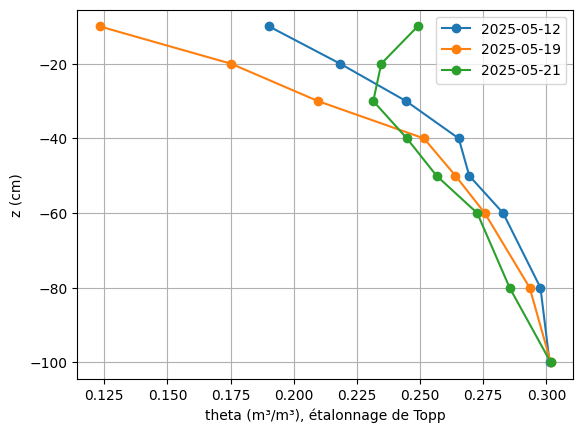

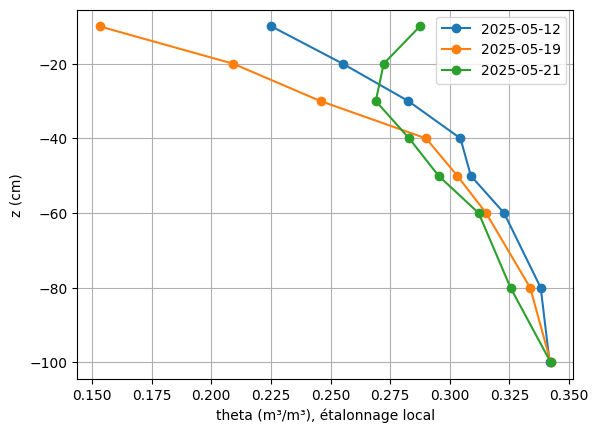

In [18]:
tdr = pd.read_csv("data/J02_tdr_profils.csv")
print(tdr)
z = tdr["profondeur_cm"].to_numpy()
dates = ["2025-05-12", "2025-05-19", "2025-05-21"]

# conversion eps -> theta de chaque date, avec les deux étalonnages
theta_topp = pd.DataFrame({"profondeur_cm": z})
theta_local = pd.DataFrame({"profondeur_cm": z})
for date in dates:
    theta_topp[date] = topp(tdr[date])
    theta_local[date] = np.polyval(coef, tdr[date])
print(theta_local.round(3))

plt.figure()
for date in dates:
    plt.plot(theta_topp[date], -z, "o-", label=date)
plt.xlabel("theta (m³/m³), étalonnage de Topp")
plt.ylabel("z (cm)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for date in dates:
    plt.plot(theta_local[date], -z, "o-", label=date)
plt.xlabel("theta (m³/m³), étalonnage local")
plt.ylabel("z (cm)")
plt.legend()
plt.grid(True)
plt.show()

**4. Stock d'eau 0–100 cm par la méthode des trapèzes**

In [19]:
# profil complété par un point en surface (z = 0) où theta = theta(10 cm)
z_complet = np.concatenate([[0.0], z])

lignes = []
for date in dates:
    th_topp = theta_topp[date].to_numpy()
    th_local = theta_local[date].to_numpy()
    th_topp_complet = np.concatenate([[th_topp[0]], th_topp])
    th_local_complet = np.concatenate([[th_local[0]], th_local])
    # intégrale de theta sur z (cm d'eau), convertie en mm
    W_topp = np.trapezoid(th_topp_complet, z_complet) * 10
    W_local = np.trapezoid(th_local_complet, z_complet) * 10
    lignes.append([date, W_topp, W_local, W_local - W_topp])

W = pd.DataFrame(lignes, columns=["date", "W_Topp_mm", "W_local_mm", "ecart_local_Topp_mm"])
print(W.round(1))

         date  W_Topp_mm  W_local_mm  ecart_local_Topp_mm
0  2025-05-12      260.4       299.1                 38.7
1  2025-05-19      238.7       276.1                 37.4
2  2025-05-21      262.3       301.2                 39.0


**5. Variation de stock entre les dates**

In [20]:
W_topp = W["W_Topp_mm"].to_numpy()
W_local = W["W_local_mm"].to_numpy()

# variation de stock entre dates successives (mm)
dW_local_12 = W_local[1] - W_local[0]
dW_local_23 = W_local[2] - W_local[1]
dW_topp_12 = W_topp[1] - W_topp[0]
dW_topp_23 = W_topp[2] - W_topp[1]
print("Variation de stock, étalonnage local : dates 1 -> 2 :", round(dW_local_12, 1), "mm ; dates 2 -> 3 :", round(dW_local_23, 1), "mm")
print("Variation de stock, étalonnage Topp  : dates 1 -> 2 :", round(dW_topp_12, 1), "mm ; dates 2 -> 3 :", round(dW_topp_23, 1), "mm")
print("-> presque identiques : le biais de l'étalonnage s'élimine par différence")

pluie_mm = 32
non_stocke = pluie_mm - dW_local_23
print("Pluie entre les dates 2 et 3 :", pluie_mm, "mm ->", round(non_stocke), "mm non stockés dans 0-100 cm (évaporation, interception, drainage)")

Variation de stock, étalonnage local : dates 1 -> 2 : -23.0 mm ; dates 2 -> 3 : 25.1 mm
Variation de stock, étalonnage Topp  : dates 1 -> 2 : -21.7 mm ; dates 2 -> 3 : 23.5 mm
-> presque identiques : le biais de l'étalonnage s'élimine par différence
Pluie entre les dates 2 et 3 : 32 mm -> 7 mm non stockés dans 0-100 cm (évaporation, interception, drainage)


**Commentaire (instructeur).** L'équation de Topp sous-estime θ de ~0,04 pour ce sol organique (biais négatif) ; le polynôme local ramène le RMSE à ~0,011.
Sur le stock, l'écart entre étalonnages atteint 37–39 mm sur 1 m : le biais se cumule sur l'épaisseur. En revanche la
*variation* de stock entre dates est presque la même avec les deux étalonnages (le biais s'élimine par différence). Entre les
dates 2 et 3, la pluie de 32 mm n'apparaît qu'en partie dans le stock (~25 mm) : le reste est évaporé, intercepté ou drainé.

## Exercice 5 — Bonus — potentiel osmotique  *(≈ facultatif)*

Calculer le potentiel osmotique de solutions de NaCl de 1 à 500 mmol/L par la loi de van 't Hoff
$\Psi_o = -i\,c\,R\,T$ ($i = 2$, $c$ en mol/m³, $R = 8{,}314$ J/(mol K), $T = 293$ K), l'exprimer en kPa et en m d'eau,
puis comparer à la règle empirique $\Psi_o$ [kPa] $\approx -36\,\mathrm{CE}$ [dS/m] avec $\mathrm{CE} \approx 0{,}107\,c^{0{,}98}$ dS/m ($c$ en mmol/L).

**Loi de van 't Hoff et règle −36 CE**

In [21]:
c_mmol = np.array([1, 5, 10, 50, 100, 500])    # mmol/L
R = 8.314        # J/(mol K)
T = 293.15       # K
i_ions = 2       # NaCl -> Na+ et Cl-

# van 't Hoff : c en mol/m³ (1 mmol/L = 1 mol/m³), résultat en Pa puis en kPa
Psi_vh_kPa = -i_ions * c_mmol * R * T / 1000
Psi_vh_m = Psi_vh_kPa * 1000 / (rho_w * g)

# règle empirique à partir de la conductivité électrique
CE = 0.107 * c_mmol**0.98
Psi_ce_kPa = -36 * CE

osm = pd.DataFrame({"c (mmol/L)": c_mmol, "CE (dS/m)": CE, "Psi_o van 't Hoff (kPa)": Psi_vh_kPa,
                    "Psi_o (m d'eau)": Psi_vh_m, "Psi_o = -36 CE (kPa)": Psi_ce_kPa})
print(osm.round(2))
print("Eau de mer (~0,6 mol/L) : Psi_o =", round(-i_ions * 600 * R * T / 1000), "kPa ; les racines ne peuvent pas l'absorber.")

   c (mmol/L)  CE (dS/m)  Psi_o van 't Hoff (kPa)  Psi_o (m d'eau)  \
0           1       0.11                    -4.87            -0.50   
1           5       0.52                   -24.37            -2.49   
2          10       1.02                   -48.74            -4.98   
3          50       4.95                  -243.72           -24.89   
4         100       9.76                  -487.45           -49.78   
5         500      47.25                 -2437.25          -248.89   

   Psi_o = -36 CE (kPa)  
0                 -3.85  
1                -18.65  
2                -36.79  
3               -178.11  
4               -351.31  
5              -1700.89  
Eau de mer (~0,6 mol/L) : Psi_o = -2925 kPa ; les racines ne peuvent pas l'absorber.


**Commentaire (instructeur).** La règle −36·CE et van 't Hoff concordent à ~10 % jusqu'à 100 mmol/L ; au-delà, la solution n'est plus idéale (coefficient osmotique < 1).

## Pour aller plus loin

* Exercice 2 : estimer le flux réel entre tensiomètres en supposant $K(h)$ de Mualem–van Genuchten pour le loam (Jour 5).
* Exercice 3 : refaire le calcul avec un angle de contact de 60° (sol hydrophobe) ; que devient la distribution ?
* Exercice 4 : propager une incertitude de ±0,5 sur $\varepsilon_a$ (Monte-Carlo) jusqu'au stock d'eau.